# Notebook 05: t-SNE Task Comparison

**Goal:** Visualize CLS token embeddings from the GNG-trained ViT across all 4 cognitive tasks to assess which task produces the most separable HC vs GAD clusters in the model's latent space.

**Design note:** All 4 tasks are embedded through the **GNG-trained model** (2026-04-27 k-fold, HbT). This is a cross-task feature probe — it shows how the GNG-optimized model represents data from each task, not a per-task independently-trained comparison. When per-task models are available with the same config, re-run with each task's own `checkpoint_dir`.

**Data leakage prevention:** For each fold k, only `val_subjects` (subjects the fold-k model never trained on) are embedded using `ViT_fold_k.pt`.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Resolve BASE: 4 levels up from this notebook's subdirectory
BASE = os.path.abspath(
    os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..', '..', '..')
)
sys.path.insert(0, os.path.join(BASE, 'src'))

from core.embed import extract_kfold_embeddings

print(f"BASE: {BASE}")

BASE: /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method


In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
CHECKPOINT_DIR = os.path.join(
    BASE, 'research', 'experiments', '20260427',
    'ViT_GNG_hbt_kfold5_ep100_bs8_p100_20260427'
)
DATA_DIR    = os.path.join(BASE, 'data', 'processed')
SPLITS_JSON = os.path.join(BASE, 'data', 'splits', 'kfold_splits.json')
OUTPUT_DIR  = os.path.dirname(os.path.abspath('__file__'))
DEVICE      = 'cpu'   # change to 'cuda' if GPU available
TASKS       = ['GNG', '1backWM', 'VF', 'SS']
RANDOM_SEED = 42

print(f"Checkpoint: {CHECKPOINT_DIR}")
print(f"Data dir:   {DATA_DIR}")
print(f"Splits:     {SPLITS_JSON}")

Checkpoint: /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method/research/experiments/20260427/ViT_GNG_hbt_kfold5_ep100_bs8_p100_20260427
Data dir:   /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method/data/processed
Splits:     /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method/data/splits/kfold_splits.json


In [3]:
# ── Load subject labels from splits JSON ─────────────────────────────────────
with open(SPLITS_JSON) as f:
    splits = json.load(f)

subject_labels = splits['subjects']   # {subject_id: 'anxiety' | 'healthy'}
label_int = {'healthy': 0, 'anxiety': 1}

print(f"Total subjects in splits: {len(subject_labels)}")
print(f"  HC: {sum(v == 'healthy' for v in subject_labels.values())}")
print(f"  GAD: {sum(v == 'anxiety' for v in subject_labels.values())}")

Total subjects in splits: 48
  HC: 32
  GAD: 16


In [4]:
# ── Extract CLS embeddings for each task ─────────────────────────────────────
# Uses GNG-trained model for all tasks (cross-task feature probe).
# Each subject's embedding comes from the fold where they were a val subject.

task_embeddings = {}

for task in TASKS:
    print(f"\n{'='*50}")
    print(f"Task: {task}")
    emb_dict = extract_kfold_embeddings(
        checkpoint_dir=CHECKPOINT_DIR,
        task=task,
        data_dir=DATA_DIR,
        splits_json=SPLITS_JSON,
        data_type='hbt',
        device=DEVICE,
        batch_size=8,
    )
    task_embeddings[task] = emb_dict

print(f"\nExtraction complete.")
for task in TASKS:
    print(f"  {task}: {len(task_embeddings[task])} subjects")


Task: GNG
[embed] Dataset loaded: GNG/hbt — 192 trials across 48 subjects


  [fold 1] Extracted 10 subjects: ['AA013', 'AA041', 'AH023', 'AH026', 'AH029', 'AH040', 'AH045', 'AH049', 'LA042', 'LA059']


  [fold 2] Extracted 10 subjects: ['AA056', 'AH018', 'AH020', 'AH021', 'AH025', 'AH027', 'AH035', 'AH046', 'LA052', 'LA063']


  [fold 3] Extracted 10 subjects: ['AH015', 'AH022', 'AH030', 'AH031', 'AH033', 'AH034', 'AH036', 'EA061', 'EA062', 'LA054']


  [fold 4] Extracted 9 subjects: ['AH019', 'AH024', 'AH028', 'AH038', 'AH048', 'AH050', 'EA060', 'LA057', 'LA058']


...

  [fold 1] Extracted 10 subjects: ['AA013', 'AA041', 'AH023', 'AH026', 'AH029', 'AH040', 'AH045', 'AH049', 'LA042', 'LA059']


  [fold 2] Extracted 10 subjects: ['AA056', 'AH018', 'AH020', 'AH021', 'AH025', 'AH027', 'AH035', 'AH046', 'LA052', 'LA063']


  [fold 3] Extracted 10 subjects: ['AH015', 'AH022', 'AH030', 'AH031', 'AH033', 'AH034', 'AH036', 'EA061', 'EA062', 'LA054']


  [fold 4] Extracted 9 subjects: ['AH019', 'AH024', 'AH028', 'AH038', 'AH048', 'AH050', 'EA060', 'LA057', 'LA058']


  [fold 5] Extracted 9 subjects: ['AA064', 'AH014', 'AH017', 'AH037', 'AH039', 'AH043', 'AH044', 'EA055', 'LA051']
[embed] Done: 48 total subjects for task=SS

Extraction complete.
  GNG: 48 subjects
  1backWM: 48 subjects
  VF: 48 subjects
  SS: 48 subjects


In [5]:
# ── Build embedding arrays with labels ───────────────────────────────────────
task_X = {}       # task -> (n_subjects, 64)
task_y = {}       # task -> (n_subjects,)  0=HC, 1=GAD
task_subjects = {}  # task -> [subject_id, ...]

for task in TASKS:
    emb_dict = task_embeddings[task]
    subjects = sorted(emb_dict.keys())
    X = np.array([emb_dict[s] for s in subjects])
    y = np.array([label_int[subject_labels[s]] for s in subjects])
    task_X[task] = X
    task_y[task] = y
    task_subjects[task] = subjects
    print(f"{task}: shape={X.shape}  HC={sum(y==0)}  GAD={sum(y==1)}")

GNG: shape=(48, 64)  HC=32  GAD=16
1backWM: shape=(48, 64)  HC=32  GAD=16
VF: shape=(48, 64)  HC=32  GAD=16
SS: shape=(48, 64)  HC=32  GAD=16


In [7]:
# ── Run t-SNE and compute silhouette score per task ──────────────────────────
task_tsne = {}
task_silhouette = {}

for task in TASKS:
    X = task_X[task]
    y = task_y[task]
    perplexity = min(15, len(X) - 1)
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=RANDOM_SEED, max_iter=2000)
    X_2d = tsne.fit_transform(X)
    task_tsne[task] = X_2d
    sil = silhouette_score(X_2d, y)
    task_silhouette[task] = sil
    print(f"{task}: silhouette = {sil:.4f}")

best_task = max(task_silhouette, key=task_silhouette.get)
print(f"\nBest separation: {best_task} (silhouette = {task_silhouette[best_task]:.4f})")

GNG: silhouette = -0.0072


1backWM: silhouette = -0.0109


VF: silhouette = -0.0388


SS: silhouette = -0.0154

Best separation: GNG (silhouette = -0.0072)


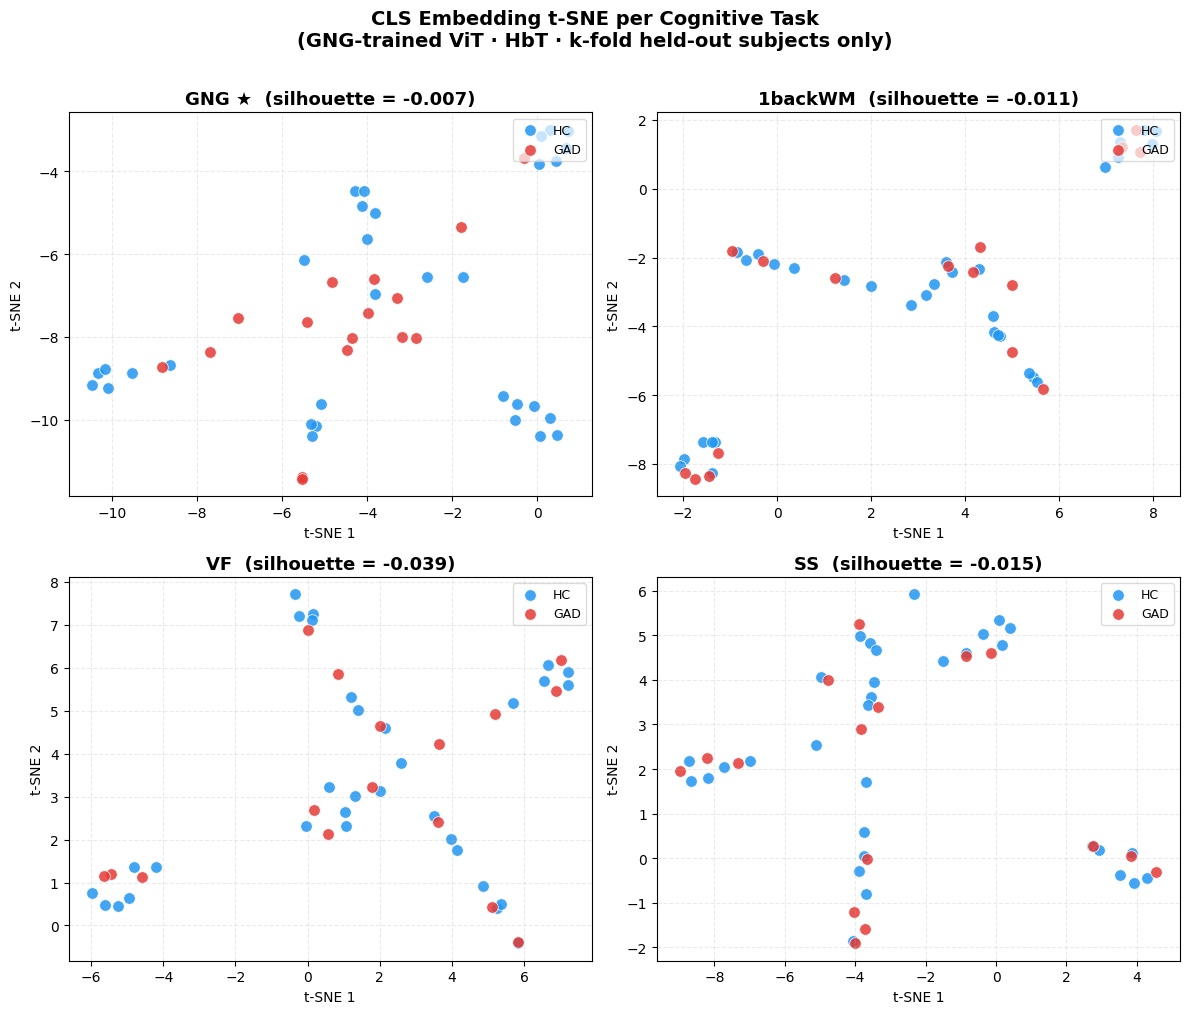

Saved: /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method/src/notebook/statistical-analysis/05_tsne_embeddings/fig_tsne_task_comparison.png


In [8]:
# ── Figure 1: 2x2 t-SNE panels per task ─────────────────────────────────────
COLORS = {0: '#2196F3', 1: '#E53935'}  # HC=blue, GAD=red
LABELS = {0: 'HC', 1: 'GAD'}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, task in zip(axes.flat, TASKS):
    X_2d = task_tsne[task]
    y    = task_y[task]
    sil  = task_silhouette[task]
    highlight = ' ★' if task == best_task else ''

    for cls in [0, 1]:
        mask = y == cls
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=COLORS[cls], label=LABELS[cls],
            alpha=0.85, s=70, edgecolors='white', linewidths=0.6
        )

    ax.set_title(f'{task}{highlight}  (silhouette = {sil:.3f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.7)
    ax.grid(True, alpha=0.25, linestyle='--')

fig.suptitle(
    'CLS Embedding t-SNE per Cognitive Task\n'
    '(GNG-trained ViT · HbT · k-fold held-out subjects only)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, 'fig_tsne_task_comparison.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

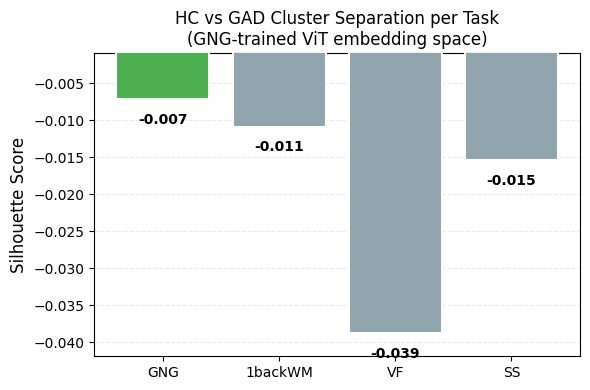

Saved: /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method/src/notebook/statistical-analysis/05_tsne_embeddings/fig_tsne_silhouette_scores.png


In [9]:
# ── Figure 2: Silhouette score bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

scores     = [task_silhouette[t] for t in TASKS]
bar_colors = ['#4CAF50' if t == best_task else '#90A4AE' for t in TASKS]

bars = ax.bar(TASKS, scores, color=bar_colors, edgecolor='white', linewidth=1.5, zorder=3)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=2)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title(
    'HC vs GAD Cluster Separation per Task\n(GNG-trained ViT embedding space)',
    fontsize=12
)
ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=1)
y_pad = max(abs(s) for s in scores) * 0.08
ax.set_ylim(min(scores) - y_pad, max(scores) + y_pad * 2)

for bar, score in zip(bars, scores):
    y_pos = bar.get_height() + y_pad * 0.4 if score >= 0 else bar.get_height() - y_pad * 1.2
    ax.text(
        bar.get_x() + bar.get_width() / 2, y_pos,
        f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
fig_path2 = os.path.join(OUTPUT_DIR, 'fig_tsne_silhouette_scores.png')
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path2}")

In [11]:
# ── Silhouette in original 64D embedding space (more rigorous) ───────────────
# t-SNE silhouette is unreliable at n=48 in 2D. 
# Computing directly on the 64D CLS vectors gives a cleaner separation measure.

task_silhouette_64d = {}

for task in TASKS:
    X = task_X[task]
    y = task_y[task]
    sil_64d = silhouette_score(X, y)
    task_silhouette_64d[task] = sil_64d
    print(f"{task}: silhouette (64D) = {sil_64d:.4f}")

best_task_64d = max(task_silhouette_64d, key=task_silhouette_64d.get)
print(f"\nBest separation (64D): {best_task_64d} (silhouette = {task_silhouette_64d[best_task_64d]:.4f})")

# Ranking comparison
print("\nRanking comparison:")
print(f"{'Task':<12} {'64D Silhouette':>16} {'2D t-SNE Silhouette':>22}")
for task in sorted(TASKS, key=lambda t: -task_silhouette_64d[t]):
    print(f"{task:<12} {task_silhouette_64d[task]:>+16.4f} {task_silhouette[task]:>+22.4f}")

GNG: silhouette (64D) = 0.0032
1backWM: silhouette (64D) = 0.0008
VF: silhouette (64D) = -0.0370
SS: silhouette (64D) = -0.0017

Best separation (64D): GNG (silhouette = 0.0032)

Ranking comparison:
Task           64D Silhouette    2D t-SNE Silhouette
GNG                   +0.0032                -0.0072
1backWM               +0.0008                -0.0109
SS                    -0.0017                -0.0154
VF                    -0.0370                -0.0388


In [10]:
# ── Summary ──────────────────────────────────────────────────────────────────
print("Task silhouette scores (higher = more separated HC/GAD clusters):")
for task in sorted(TASKS, key=lambda t: -task_silhouette[t]):
    marker = ' ← best' if task == best_task else ''
    print(f"  {task:10s}: {task_silhouette[task]:+.4f}{marker}")

print("\nNote: All tasks embedded through GNG-trained model (cross-task feature probe).")
print("When per-task models are available, re-run with each task's own checkpoint_dir.")

Task silhouette scores (higher = more separated HC/GAD clusters):
  GNG       : -0.0072 ← best
  1backWM   : -0.0109
  SS        : -0.0154
  VF        : -0.0388

Note: All tasks embedded through GNG-trained model (cross-task feature probe).
When per-task models are available, re-run with each task's own checkpoint_dir.
